# Tool catalog: image and video transforms

Run these cells in order in a disposable JupyterLab project with its live Python kernel and selected ChatGPT connection. The 64×64 PNG is created here; the video is a real recording of an owned notebook tab. Both inputs have exact SHA-256 references. The browser decodes actual frames and creates separate derivatives without altering either source. Wait for each receipt to finish before inspecting it in a later cell. The AI questions make scoped tool calls using these inputs.


The saved Python results and AI answers come from separate runs of this notebook, so their temporary folder names and operation IDs differ. When you run it, start with setup and use the values from your current run.


## Exact PNG and recorded notebook-tab video

[Download the companion screen recording](https://github.com/rahuldave/nbinlineai/blob/main/examples/media/owned-notebook-tab-2087303b97be.webm) and place it in `media/owned-notebook-tab-2087303b97be.webm` beside a standalone downloaded notebook for offline use. The setup also checks `examples/media/owned-notebook-tab-2087303b97be.webm` in a repository checkout. If the file is absent, it fetches that exact published file over HTTPS, checks its size and SHA-256, then makes a disposable local copy. Keep the kernel working directory at the Jupyter server root.


In [1]:
from pathlib import Path
from tempfile import mkdtemp
from hashlib import sha256
from urllib.request import urlopen
from PIL import Image, ImageDraw
from nbinlineai.tools import extract_frames, crop_image, annotate_image, operation_status, release_media

clip_name = 'owned-notebook-tab-2087303b97be.webm'
clip_sha256 = '2087303b97be4ba56da4d95d19d1106f6c0ddb5d9030e3f74f5c47e84bc4d63a'
clip_size = 72134
clip_url = 'https://raw.githubusercontent.com/rahuldave/nbinlineai/main/examples/media/owned-notebook-tab-2087303b97be.webm'
local_clips = [Path.cwd() / 'examples' / 'media' / clip_name, Path.cwd() / 'media' / clip_name]
local_clip = next((candidate for candidate in local_clips if candidate.is_file()), None)
if local_clip is not None:
    if local_clip.stat().st_size != clip_size:
        raise ValueError(f'Companion clip has the wrong size: {local_clip}')
    clip_bytes = local_clip.read_bytes()
else:
    try:
        with urlopen(clip_url, timeout=10) as response:
            clip_bytes = response.read(clip_size + 1)
    except OSError as error:
        raise RuntimeError(f'Download {clip_url} and put it in media/{clip_name} beside this notebook.') from error
if len(clip_bytes) != clip_size or sha256(clip_bytes).hexdigest() != clip_sha256:
    raise ValueError('Companion clip size or SHA-256 differs from the published recording.')

work = Path(mkdtemp(prefix='nbinlineai-transform-', dir=Path.cwd()))
image_path = work / 'source.png'
video_path = work / clip_name
image = Image.new('RGB', (64, 64), 'white')
ImageDraw.Draw(image).rectangle((4, 4, 20, 20), fill='red')
image.save(image_path, format='PNG')
video_path.write_bytes(clip_bytes)
image_ref = {'path': image_path.relative_to(Path.cwd()).as_posix(), 'sha256': sha256(image_path.read_bytes()).hexdigest()}
video_ref = {'path': video_path.relative_to(Path.cwd()).as_posix(), 'sha256': clip_sha256}
print('Exact created PNG and recorded notebook-tab clip:', image_ref, video_ref)
from IPython.display import display, HTML
from base64 import b64encode
from html import escape
video_uri = 'data:video/webm;base64,' + b64encode(clip_bytes).decode('ascii')
display(HTML(f'<video controls preload="metadata" width="320" src="{escape(video_uri, quote=True)}"></video>'))


Exact created PNG and recorded notebook-tab clip: {'path': 'nbinlineai-transform-v5x45ohi/source.png', 'sha256': '634c6cc561e039ccc2073df913453ea426885c9d9e964a246f04251642236a50'} {'path': 'nbinlineai-transform-v5x45ohi/owned-notebook-tab-2087303b97be.webm', 'sha256': '2087303b97be4ba56da4d95d19d1106f6c0ddb5d9030e3f74f5c47e84bc4d63a'}


## extract_frames

Decode two positions from the owned notebook-tab recording. The receipt includes actual decoded frame times and Pillow images; this memory-only request does not save a file. The two requested positions sample different visible notebook scenes.


In [2]:
from nbinlineai.tools import extract_frames
frames = extract_frames(video_ref, [1.5, 5.0])
frames


BrowserReceipt(operation_id=None, status='running')

Frame extraction: completed None
Actual presented seconds: [1.046, 4.674]


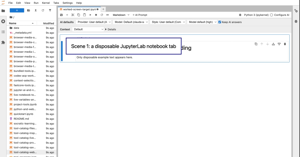

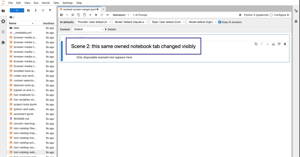

In [3]:
from IPython.display import display
from PIL import ImageChops
print('Frame extraction:', frames.status, frames.error)
if frames.status == 'completed':
    assert len(frames.result) == len(frames.media) == 2
    assert all(item.size == (1500, 786) for item in frames.result)
    assert [item['source_sha256'] for item in frames.media] == [video_ref['sha256']] * 2
    assert 0 <= frames.media[0]['actual_seconds'] < frames.media[1]['actual_seconds']
    assert ImageChops.difference(frames.result[0].convert('RGB'), frames.result[1].convert('RGB')).getbbox(), 'The two decoded notebook scenes should differ.'
    print('Actual presented seconds:', [item['actual_seconds'] for item in frames.media])
    for frame in frames.result:
        display(frame.copy().resize((300, 157)))


Use &`extract_frames` on the exact owned notebook-tab recording $`video_ref` at 1.5 and 5.0 seconds. Report only the immediate operation ID/state; the later status checks actual decoded times.


Operation ID: `QQC9jKW7UGbs9Nnx1e8DKTG2o7FjZOda`; state: `running`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `extract_frames` | receipt accepted | {"media":{"path":"nbinlineai-transform-eul8qr4s/owned-notebook-tab-2087303b97be.webm","sha256":"2087303b97be4ba56da4d95d19d1106f6c0ddb5d9030e3f74f5c47e84bc4d63a"},"timestamps":[1.5,5]} | {"operation_id":"QQC9jKW7UGbs9Nnx1e8DKTG2o7FjZOda","status":"running"} |


After extraction completes, use &`operation_status` on its exact operation ID. Report actual frame timestamps, dimensions, source hash, and managed media IDs if present; do not infer actual times from requested times. The direct Python inspection above checks that both decoded notebook scenes differ.


Extraction completed. Both frames are 1500×786 and have source SHA-256 `2087303b97be4ba56da4d95d19d1106f6c0ddb5d9030e3f74f5c47e84bc4d63a`.

- Actual time **1.046 s** — media ID `zjKw4QzFlmPzDoN_nDQ5Fw0pqh2DgUR4`
- Actual time **4.674 s** — media ID `qzDTKkolob4D6lUMK6aBXfsExiYpCtTf`

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"QQC9jKW7UGbs9Nnx1e8DKTG2o7FjZOda"} | {"operation_id":"QQC9jKW7UGbs9Nnx1e8DKTG2o7FjZOda","status":"completed","result":{"media_count":2,"expected_count":2},"media":[{"media_id":"zjKw4QzFlmPzDoN_nDQ5Fw0pqh2DgUR4","mime_type":"image/png","bytes":260299,"sha256":"a9ace29361c61db9f0672514d05941089a8ab66a3bc2eb0dd6c5f335f433121f","expires_at":1790671969.512827,"source_sha256":"2087303b97be4ba56da4d95d19d1106f6c0ddb5d9030e3f74f5c47e84bc4d63a","transform":"extract_frames","actual_seconds":1.046,"width":1500,"height":786},{"media_id":"qzDTKkolob4D6lUMK6aBXfsExiYpCtTf","mime_type":"image/png","bytes":262453,"sha256":"f694f8480db04175f4b9d523cdc12c9d3a31c29f1d813904bede4403e4b56958","expires_at":1790671969.5558422,"source_sha256":"2087303 |


## crop_image

Crop the generated PNG to a new 16×16 image and explicitly save it. The source remains 64×64; the saved derivative has its own JSON provenance sidecar.


In [4]:
from nbinlineai.tools import crop_image
crop = crop_image(image_ref, 4, 4, 16, 16, save_to=f'{work.name}/crop.png')
crop


BrowserReceipt(operation_id=None, status='running')

completed None
(16, 16) nbinlineai-transform-v5x45ohi/crop.png nbinlineai-transform-v5x45ohi/crop.png.json


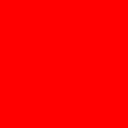

In [5]:
print(crop.status, crop.error)
if crop.status == 'completed':
    import json
    assert crop.result.size == (16, 16)
    assert crop.result.getpixel((2, 2))[:3] == (255, 0, 0)
    assert image_path.exists() and Image.open(image_path).size == (64, 64)
    sidecar = json.loads(Path(crop.media['sidecar_path']).read_text())
    assert sidecar['source_sha256'] == image_ref['sha256']
    assert sidecar['transform'] == 'crop_image'
    print(crop.result.size, crop.media['path'], crop.media['sidecar_path'])
    display(crop.result.resize((128, 128)))


Use &`crop_image` on $`image_ref` at x=4, y=4, width=16, height=16, in memory only. Report only the immediate operation ID/state; do not claim dimensions before decode completes.


Operation ID: `PYY5JZ0XIJk90MJvoPv3dDRqIgCMMuEO`; state: `running`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `crop_image` | receipt accepted | {"media":{"path":"nbinlineai-transform-eul8qr4s/source.png","sha256":"634c6cc561e039ccc2073df913453ea426885c9d9e964a246f04251642236a50"},"x":4,"y":4,"width":16,"height":16} | {"operation_id":"PYY5JZ0XIJk90MJvoPv3dDRqIgCMMuEO","status":"running"} |


Use &`operation_status` on the AI `crop_image` operation ID after completion. Report actual derivative dimensions, hash, and managed media ID; the original generated PNG remains unchanged.


Crop completed: **16×16 PNG**, SHA-256 `9b6075df6a249834074857098aa8fab09756bd8c77b97ebbf078d800062b91e6`; managed media ID `rqPcA3k75tPpxNCa36o1XOBtAOFhmlh8`. The original PNG remains unchanged.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"PYY5JZ0XIJk90MJvoPv3dDRqIgCMMuEO"} | {"operation_id":"PYY5JZ0XIJk90MJvoPv3dDRqIgCMMuEO","status":"completed","media":{"media_id":"rqPcA3k75tPpxNCa36o1XOBtAOFhmlh8","mime_type":"image/png","bytes":113,"sha256":"9b6075df6a249834074857098aa8fab09756bd8c77b97ebbf078d800062b91e6","expires_at":1790671998.8154619,"source_sha256":"634c6cc561e039ccc2073df913453ea426885c9d9e964a246f04251642236a50","transform":"crop_image","width":16,"height":16}} |


## annotate_image

Create a distinct PNG with an opaque black redaction over part of the original red square, plus a rectangle, arrow, and short text. Inspect a redacted pixel and the unchanged source pixel later. This memory-only derivative has no sidecar.


In [6]:
from nbinlineai.tools import annotate_image
shapes = [
    {'type': 'redaction', 'x': 5, 'y': 5, 'width': 8, 'height': 8},
    {'type': 'rectangle', 'x': 22, 'y': 5, 'width': 16, 'height': 12, 'color': '#1976d2'},
    {'type': 'arrow', 'x1': 3, 'y1': 40, 'x2': 25, 'y2': 40, 'color': '#e53935'},
    {'type': 'text', 'x': 30, 'y': 35, 'text': 'demo', 'font_size': 12, 'color': '#000000'},
]
annotated = annotate_image(image_ref, shapes)
annotated


BrowserReceipt(operation_id=None, status='running')

completed None
Opaque redaction changed derivative pixels; source stayed red


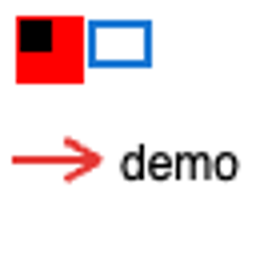

In [7]:
print(annotated.status, annotated.error)
if annotated.status == 'completed':
    assert annotated.result.size == (64, 64)
    assert annotated.result.getpixel((7, 7))[:3] == (0, 0, 0)
    assert Image.open(image_path).getpixel((7, 7)) == (255, 0, 0)
    assert annotated.media['source_sha256'] == image_ref['sha256']
    assert annotated.media['transform'] == 'annotate_image'
    print('Opaque redaction changed derivative pixels; source stayed red')
    display(annotated.result.resize((256, 256)))


Use &`annotate_image` on $`image_ref` with one opaque redaction rectangle at x=5, y=5, width=8, height=8. Report only the immediate operation ID/state; the later status checks the derivative.


Operation ID: `AY14NfWLU1LRoej6ektavA_tAGAAkgLw`; state: `running`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `annotate_image` | receipt accepted | {"media":{"path":"nbinlineai-transform-eul8qr4s/source.png","sha256":"634c6cc561e039ccc2073df913453ea426885c9d9e964a246f04251642236a50"},"annotations":[{"type":"redaction","x":5,"y":5,"width":8,"height":8}]} | {"operation_id":"AY14NfWLU1LRoej6ektavA_tAGAAkgLw","status":"running"} |


Use &`operation_status` on the AI `annotate_image` operation ID after completion. Report actual dimensions, hash, and managed media ID; the direct Python inspection above verifies changed and unchanged pixels.


Annotation completed: **64×64 PNG**, SHA-256 `a72e9220b9611c7ad7ccaf9d4841e0cd4b0a5214a00dbebf697665c67d80161e`; managed media ID `RW_dKDMbNUzqKJIbIieh-SnCLRuU7AaL`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"AY14NfWLU1LRoej6ektavA_tAGAAkgLw"} | {"operation_id":"AY14NfWLU1LRoej6ektavA_tAGAAkgLw","status":"completed","media":{"media_id":"RW_dKDMbNUzqKJIbIieh-SnCLRuU7AaL","mime_type":"image/png","bytes":311,"sha256":"a72e9220b9611c7ad7ccaf9d4841e0cd4b0a5214a00dbebf697665c67d80161e","expires_at":1790672027.105483,"source_sha256":"634c6cc561e039ccc2073df913453ea426885c9d9e964a246f04251642236a50","transform":"annotate_image","width":64,"height":64}} |


Use &`release_media` only on the exact managed IDs reported by the completed AI frame, crop, and annotation statuses. Report each release operation ID/state. If a status omitted an ID, skip it instead of guessing.


- Frame 1: `-JmFfw5AKn5MpPFuaVBNv54d6oa7avwG` — released
- Frame 2: `CYf-IHKJ4p4j8xayhLhd7n4MAouxZfSs` — released
- Crop: `gJbyZzEgxPzjyeDiyY5-z3SWzz4l-4q3` — released
- Annotation: `UueH8DRJ5m5PjLuzC-nGTjnASAgCAB4c` — released

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `release_media` | completed | {"media_id":"zjKw4QzFlmPzDoN_nDQ5Fw0pqh2DgUR4"} | {"operation_id":"-JmFfw5AKn5MpPFuaVBNv54d6oa7avwG","released":true} |
| `release_media` | completed | {"media_id":"qzDTKkolob4D6lUMK6aBXfsExiYpCtTf"} | {"operation_id":"CYf-IHKJ4p4j8xayhLhd7n4MAouxZfSs","released":true} |
| `release_media` | completed | {"media_id":"rqPcA3k75tPpxNCa36o1XOBtAOFhmlh8"} | {"operation_id":"gJbyZzEgxPzjyeDiyY5-z3SWzz4l-4q3","released":true} |
| `release_media` | completed | {"media_id":"RW_dKDMbNUzqKJIbIieh-SnCLRuU7AaL"} | {"operation_id":"UueH8DRJ5m5PjLuzC-nGTjnASAgCAB4c","released":true} |


After the AI release media rows finish, use &`operation_status` on each exact release operation ID from the prior answer. Report actual terminal states without guessing which frame was released.


All four release operations **completed** with `released: true`:

- Frame 1 (`-JmFfw5AKn5MpPFuaVBNv54d6oa7avwG`)
- Frame 2 (`CYf-IHKJ4p4j8xayhLhd7n4MAouxZfSs`)
- Crop (`gJbyZzEgxPzjyeDiyY5-z3SWzz4l-4q3`)
- Annotation (`UueH8DRJ5m5PjLuzC-nGTjnASAgCAB4c`)

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"-JmFfw5AKn5MpPFuaVBNv54d6oa7avwG"} | {"operation_id":"-JmFfw5AKn5MpPFuaVBNv54d6oa7avwG","status":"completed","result":{"released":true}} |
| `operation_status` | completed | {"operation_id":"CYf-IHKJ4p4j8xayhLhd7n4MAouxZfSs"} | {"operation_id":"CYf-IHKJ4p4j8xayhLhd7n4MAouxZfSs","status":"completed","result":{"released":true}} |
| `operation_status` | completed | {"operation_id":"gJbyZzEgxPzjyeDiyY5-z3SWzz4l-4q3"} | {"operation_id":"gJbyZzEgxPzjyeDiyY5-z3SWzz4l-4q3","status":"completed","result":{"released":true}} |
| `operation_status` | completed | {"operation_id":"UueH8DRJ5m5PjLuzC-nGTjnASAgCAB4c"} | {"operation_id":"UueH8DRJ5m5PjLuzC-nGTjnASAgCAB4c","status":"completed","result":{"released":true}} |


## Clean up disposable files

After inspecting the receipts, remove only this notebook’s generated files and empty folder. Python PIL images already delivered remain in memory until you discard them.


In [8]:
if globals().get('_released_work') != work:
    released_derivatives = {}
    seen_media_ids = set()
    for label, name in [('frames', 'frames'), ('crop', 'crop'), ('annotation', 'annotated')]:
        receipt = globals().get(name)
        if receipt is None:
            continue
        descriptors = receipt.media if receipt.status == 'completed' else None
        for descriptor in (descriptors if isinstance(descriptors, list) else [descriptors]):
            media_id = descriptor.get('media_id') if isinstance(descriptor, dict) else None
            if media_id and media_id not in seen_media_ids:
                seen_media_ids.add(media_id)
                released_derivatives[f'{label} {len(released_derivatives) + 1}'] = release_media(media_id)
    for path in (work / 'crop.png.json', work / 'crop.png', image_path, video_path):
        path.unlink(missing_ok=True)
    work.rmdir()
    _released_work = work
    print('Disposable source and derivative files removed; release receipts follow.')
print('Disposable source and derivative files removed:', not work.exists())
for label, receipt in released_derivatives.items():
    print(label, receipt.status, receipt.error)


Disposable source and derivative files removed; release receipts follow.
Disposable source and derivative files removed: True
frames 1 running None
frames 2 running None
crop 3 running None
annotation 4 running None
